# 文本分析

## 英语词频分析

### 英语分词规则 

In [1]:
#英语分词使用空格分隔
s= "This is an example sentence to demonstrate English tokenization."  
s.split() 

['This',
 'is',
 'an',
 'example',
 'sentence',
 'to',
 'demonstrate',
 'English',
 'tokenization.']

### 统计词频

In [2]:
from collections import Counter
tokens = s.split()
word_counts = Counter(tokens) 
for word, count in word_counts.most_common(10):
    print(word, count)

This 1
is 1
an 1
example 1
sentence 1
to 1
demonstrate 1
English 1
tokenization. 1


### 案例讲解

In [3]:
txt = open("X-hamlet.txt", "r").read() #读取文件
for ch in '# $ % & () * + , - . : ; < = > ? @ [\\] ^ {}':
    txt = txt.replace(ch, " ") # 通过replace()函数将空格替换特殊字符
txt = txt.lower() #将所有的字母转化为小写
tokens = txt.split()
word_counts = Counter(tokens) 
for word, count in word_counts.most_common(10):
    print(word, count)

the 1138
and 965
to 754
of 668
you 549
a 542
i 540
my 514
hamlet 456
in 436


### 去除停用词

In [4]:
#安装wordcloud--pip.install.wordcloud
from wordcloud import STOPWORDS
print(STOPWORDS)

{'and', "they'd", 'com', "we'd", 'with', 'therefore', 'been', 'hence', 'myself', 'being', 'be', 'not', 'after', 'doing', 'at', 'you', 'from', "aren't", 'hers', "don't", "he's", 'no', "can't", 'otherwise', 'into', 'are', 'out', 'again', 'its', "isn't", 'that', "that's", 'herself', 'she', "won't", 'this', "couldn't", 'some', "what's", 'their', 'while', 'just', 'like', 'most', "hasn't", "you'll", 'during', 'as', "haven't", "we've", 'http', 'but', 'own', "wouldn't", "let's", 'more', 'there', 'our', 'does', "i'll", 'by', 'very', 'each', 'under', "they've", 'ever', 'else', "he'll", 'can', 'her', 'those', "shouldn't", 'than', 'few', 'then', "hadn't", 'off', "weren't", 'any', 'himself', "she'll", "they'll", 'too', "doesn't", 'having', 'since', 'should', 'them', 'did', 'r', 'between', 'against', 'www', "you'd", 'an', 'had', "you've", 'i', 'get', 'also', 'ours', 'why', 'how', 'theirs', "there's", 'however', 'or', 'over', 'only', 'other', "they're", "we'll", 'whom', 'all', "why's", 'have', 'who',

## 英语词云图 

In [5]:
from matplotlib import pyplot as plt
txt = open ("X-hamlet.txt").read()
stopwords = STOPWORDS

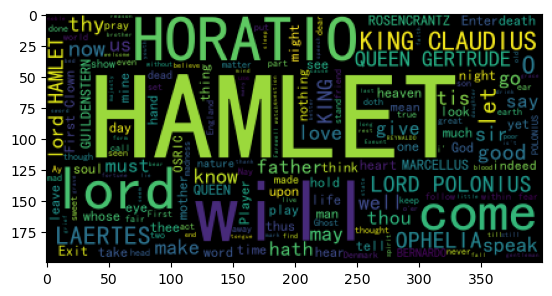

In [6]:
from wordcloud import WordCloud #注意两个wordcloud的大小写要正确
wc = WordCloud(stopwords=stopwords)
wc.generate(txt)
plt.imshow(wc)
#如果报错，可能是字体问题。加一条字体定义

## 中文词频分析

### 安装Jieba  

In [7]:
# windows 在prompt里 pip install jieba
# Mac 直接在python命令行里 pip install jieba

In [8]:
import jieba
import pandas as pd

C:\Users\hp\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hp\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### 中文分词 

#### 字典法：常用


In [9]:
#字典法：常用
text = open ("X_Red.txt", encoding='UTF-8').read()
words  = jieba.lcut(text)
excludes = {"听见","进来","东西","一个","我们","什么","自己","他们","如今","那里","没有","两个","怎么","这里","你们"}
counts = {}
for word in words:
    if len(word) == 1:  #排除单个字符的分词结果
        continue
    elif word == "老太太" or word == "贾夫人":
        rword = "贾母"
    elif word == "混世魔王" or word == "宝哥哥"  or word == "宝兄弟":
        rword = "宝玉"
    elif word == "王熙凤" or word == "凤丫头"  or word == "凤哥" or word == "凤姐儿":
        rword = "凤姐"
    elif word == "林姑娘" or word == "林妹妹"  or word == "潇湘妃子":
        rword = "黛玉"
    else:
        rword = word
    counts[rword] = counts.get(rword,0) + 1
for word in excludes:
     del counts[word]
items = list(counts.items())
items.sort(key=lambda x:x[1], reverse=True) 
for i in range(20):
    word, count = items[i]
    print ("{0:<10}{1:>5}".format(word, count))


Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\hp\AppData\Local\Temp\jieba.cache
Loading model cost 0.540 seconds.
Prefix dict has been built successfully.


宝玉         3836
贾母         2202
凤姐         1655
王夫人        1018
说道          978
知道          973
起来          956
姑娘          949
出来          930
众人          872
奶奶          848
一面          828
太太          825
只见          793
黛玉          788
不是          744
不知          712
这个          697
贾琏          672
这样          656


#### 代码块Counter法

In [10]:
#代码块Counter法
import jieba
from collections import Counter
with open("X_Red.txt", "r",encoding="utf-8") as f:
    words = jieba.lcut(f.read())
    words = [item for item in words if len(item)>1]
counts = Counter(words)
for word,count in counts.most_common(10):
    print(word,count)
print ('词频排前10的词')

宝玉 3776
什么 1616
一个 1453
贾母 1231
我们 1227
那里 1179
凤姐 1100
王夫人 1018
如今 1004
你们 1004
词频排前10的词


#### 使用nltk包

In [11]:
#使用nltk包，先安装
import jieba,os
from nltk.probability import FreqDist
with open("X_Red.txt","r",encoding="utf-8") as f:
    text = f.read()
words = jieba.lcut(text)
lst = [i for i in words if len(i)>1]
freq = FreqDist(lst)
for item in freq.most_common(10):
    word,count=item
    print(f"{word:<10}\t{count:<5}")
print ('数量排前10的词')

C:\Users\hp\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


宝玉        	3776 
什么        	1616 
一个        	1453 
贾母        	1231 
我们        	1227 
那里        	1179 
凤姐        	1100 
王夫人       	1018 
如今        	1004 
你们        	1004 
数量排前10的词


### 中文词云图 

In [12]:
def stopwordslist():
    stopwords = [line.strip() for line in open('stopwords.txt',encoding='UTF-8').readlines()]
    return stopwords

In [13]:
# 中文分词并且去停用词
def seg_depart(sentence):
    sentence_depart = jieba.cut(sentence.strip()) 
    stopwords = stopwordslist()
    outstr = ''
    for word in sentence_depart:
        if word not in stopwords:
            if word != '/t':
                outstr += word
                outstr += " "
    return outstr

In [14]:
# 指定中文字体路径（Windows系统） 解决中文显示问题
# font_path = 'C:/Windows/Fonts/msyh.ttc'  # 微软雅黑
# wc = WordCloud(font_path=font_path, width=800, height=600, background_color='white')


filename = "X_Red.txt"
outfilename = "X_Red_seg.txt"
inputs = open(filename, 'r',encoding='UTF-8')
outputs = open(outfilename, 'w',encoding='UTF-8')

In [15]:
for line in inputs:
    line_seg = seg_depart(line)
    outputs.write(line_seg + '\n')

In [16]:
outputs.close()
inputs.close()

In [17]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

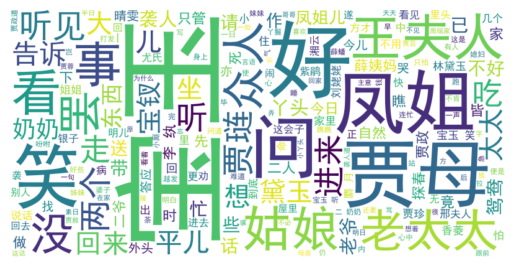

In [19]:
font_path = 'C:/Windows/Fonts/msyh.ttc'  # 微软雅黑
text = open ("X_Red_seg.txt", encoding='UTF-8').read()
word_list = jieba.cut(text)  # Use jieba to tokenize the text
word_str = " ".join(word_list) # Join the list of words into a string
wordcloud = WordCloud(font_path=font_path, width=800, height=400, background_color="white").generate(word_str)
plt.imshow(wordcloud, interpolation='bilinear') # Display the generated image
plt.axis("off")
plt.show()

In [27]:
filename = "Shanxi.txt"
outfilename = "X_Shanxi.txt"
inputs = open(filename, 'r',encoding='UTF-8')
outputs = open(outfilename, 'w',encoding='UTF-8')

for line in inputs:
    line_seg = seg_depart(line)
    outputs.write(line_seg + '\n')
    
outputs.close()
inputs.close()

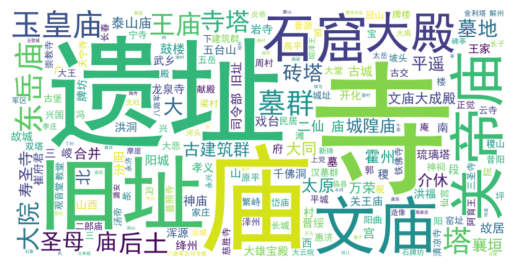

In [28]:
text = open ("X_Shanxi.txt", encoding='UTF-8').read()
word_list = jieba.cut(text)  # Use jieba to tokenize the text
word_str = " ".join(word_list) # Join the list of words into a string
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(word_str)
plt.imshow(wordcloud, interpolation='bilinear') # Display the generated image
plt.axis("off")
plt.show()

## 案例：Wei blog

In [20]:
import jieba
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [21]:
def stopwordslist():
    stopwords = [line.strip() for line in open('stopwords.txt',encoding='UTF-8').readlines()]
    return stopwords

# 中文分词并且去停用词
def seg_depart(sentence):
    sentence_depart = jieba.cut(sentence.strip()) 
    stopwords = stopwordslist()
    outstr = ''
    for word in sentence_depart:
        if word not in stopwords:
            if word != '/t':
                outstr += word
                outstr += " "
    return outstr

filename = "wei-blog.txt"
outfilename = "wei-blog_seg.txt"
inputs = open(filename, 'r',encoding='UTF-8')
outputs = open(outfilename, 'w',encoding='UTF-8')

for line in inputs:
    line_seg = seg_depart(line)
    outputs.write(line_seg + '\n')

outputs.close()
inputs.close()

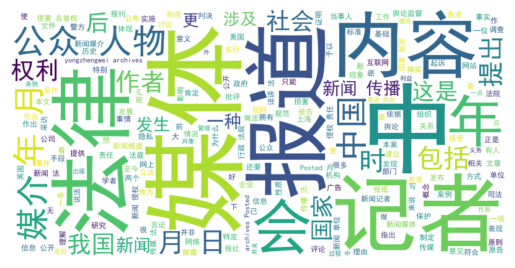

In [22]:
text = open ("wei-blog_seg.txt", encoding='UTF-8').read()
word_list = jieba.cut(text)  # Use jieba to tokenize the text
word_str = " ".join(word_list) # Join the list of words into a string
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(word_str)
plt.imshow(wordcloud, interpolation='bilinear') # Display the generated image
plt.axis("off")
plt.show()

In [23]:
#字典法：常用
# 排除不需要分析的词
# 合并公司名称，注意合并时，要检查是否有不同公司用了同一个词 
text = open ("wei-blog.txt", encoding='UTF-8').read()
words  = jieba.lcut(text)
excludes = {"包括","archives","Posted","可以","没有","一个","就是","但是","我们","对于","不是","有关","这个","可能","如果","必须","自己","不能"}
counts = {}
for word in words:
    if len(word) == 1:  #排除单个字符的分词结果
        continue
    elif word == "媒体" or word == "媒介":
        rword = "媒体"
    else:
        rword = word
    counts[rword] = counts.get(rword,0) + 1
for word in excludes:
     del counts[word]
items = list(counts.items())
items.sort(key=lambda x:x[1], reverse=True) 
for i in range(100):
    word, count = items[i]
    print ("{0:<10}{1:>5}".format(word, count))
print ('数量排前50的词')

新闻         9076
媒体         6481
规定         4941
法律         4583
信息         3697
传播         3427
问题         3311
报道         3266
侵权         3200
国家         2843
记者         2709
内容         2657
社会         2491
行为         2429
公众         2316
中国         2275
公开         2220
这样         2136
权利         2094
保护         2050
我国         1929
名誉权        1894
事实         1803
诽谤         1784
政府         1669
所以         1658
进行         1648
责任         1621
这种         1615
认为         1593
什么         1539
法院         1523
应该         1507
这些         1480
侵害         1466
自由         1460
原则         1452
案件         1449
评论         1443
研究         1442
主要         1437
发生         1431
网络         1408
或者         1405
作为         1389
作者         1375
具有         1367
还是         1363
通过         1358
应当         1357
意见         1347
需要         1341
发表         1339
关于         1329
公民         1328
人物         1321
已经         1317
他们         1287
一些         1281
发布         1267
提出         1266
使用         1254
文章      

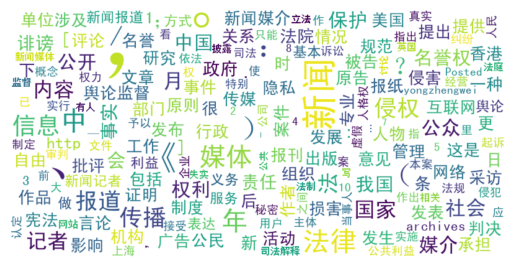

In [24]:
# 读取文本文件 
with open("wei-blog_seg.txt", encoding='UTF-8') as f:  
    text = f.read()  

# 替换换行符为空格
text = text.replace('\n', ' ')  # 替换为空格  
    
# 使用jieba进行分词，并获取词频 
word_freq = jieba.lcut(text, cut_all=False, use_paddle=True)  
from collections import Counter  
word_freq_dict = Counter(word_freq) 
  
# 生成词云  
wordcloud = WordCloud(font_path='simhei.ttf',width=800, height=400, background_color="white").generate_from_frequencies(word_freq_dict)  
# 显示词云图  
plt.imshow(wordcloud, interpolation='bilinear')  
plt.axis("off")  
plt.show()
# 这串代码可以在python里面不重复显示词